# Búsqueda Informada: Estrategias Inteligentes

## 3. Búsqueda Primero el Mejor Voraz (Greedy Best-First)

In [13]:
# Heurísticas: Distancia a 'F'
heuristics = {'A': 10, 'B': 8, 'C': 7, 'D': 4, 'E': 2, 'F': 0}
# Grafo de ciudades
graph = {'A': ['B', 'C'], 'B': ['D'], 'C': ['E'], 'D': ['F'], 'E': ['F']}

In [21]:
import heapq # Usamos una cola de prioridad

def greedy_best_first(graph, start, goal, heuristics):
    visited = set()
    # La cola guarda tuplas: (heurística, nodo, camino)
    priority_queue = [(heuristics[start], start, [start])]
    
    while priority_queue:
        # Saca el nodo con la menor heurística
        h, node, path = heapq.heappop(priority_queue)
        
        if node == goal:
            return path
        
        if node not in visited:
            visited.add(node)
            print(f"Visitando: {node}")
            for neighbor in graph[node]:
                heapq.heappush(priority_queue, (heuristics[neighbor], neighbor, path + [neighbor]))
    return None

## 4. Ascenso a la Colina (Hill Climbing)

In [15]:
def hill_climbing(graph, start, goal, heuristics):
    current_node = start
    path = [current_node]
    
    while current_node != goal:
        best_neighbor = None
        best_h = heuristics[current_node]
        
        for neighbor in graph[current_node]:
            if heuristics[neighbor] < best_h:
                best_h = heuristics[neighbor]
                best_neighbor = neighbor
        
        if best_neighbor is None:
            return "Atascado en un máximo local"
        
        current_node = best_neighbor
        path.append(current_node)
        
    return path
                     

## 5. Ramificación y Acotación (Branch and Bound)

In [16]:
# Grafo con costos reales de viaje
weighted_graph = {
    'A': {'B': 5, 'C': 2},
    'B': {'D': 4},
    'C': {'D': 8},
    'D': {}
}

In [17]:
def branch_and_bound(graph, start, goal):
    priority_queue = [(0, start, [start])] # (costo, nodo, camino)
    best_solution_cost = float('inf')
    best_path = None

    while priority_queue:
        cost, node, path = heapq.heappop(priority_queue)

        # Poda: si este camino ya es peor, descártalo.
        if cost >= best_solution_cost:
            continue

        if node == goal:
            # Encontramos una solución (quizás mejor)
            best_solution_cost = cost
            best_path = path
            continue

        for neighbor, weight in graph[node].items():
            new_cost = cost + weight
            if new_cost < best_solution_cost:
                heapq.heappush(priority_queue, (new_cost, neighbor, path + [neighbor]))
    
    return best_path, best_solution_cost

In [22]:
# Resultados de cada algoritmo
ruta_greedy = greedy_best_first(graph, 'A', 'F', heuristics)
print("Greedy Best-First:", ruta_greedy)
print("Hill Climbing:", hill_climbing(graph, 'A', 'F', heuristics))

# Grafo con costos reales de viaje para Branch and Bound
weighted_graph = {
    'A': {'B': 5, 'C': 2},
    'B': {'D': 4},
    'C': {'D': 8},
    'D': {}
}

ruta_bb, costo_bb = branch_and_bound(weighted_graph, 'A', 'D')
print("Branch and Bound:", ruta_bb, "- Costo total:", costo_bb)

Visitando: A
Visitando: C
Visitando: E
Greedy Best-First: ['A', 'C', 'E', 'F']
Hill Climbing: ['A', 'C', 'E', 'F']
Branch and Bound: ['A', 'B', 'D'] - Costo total: 9


# Gráficos

## 1. GREEDY BEST-FIRST SEARCH

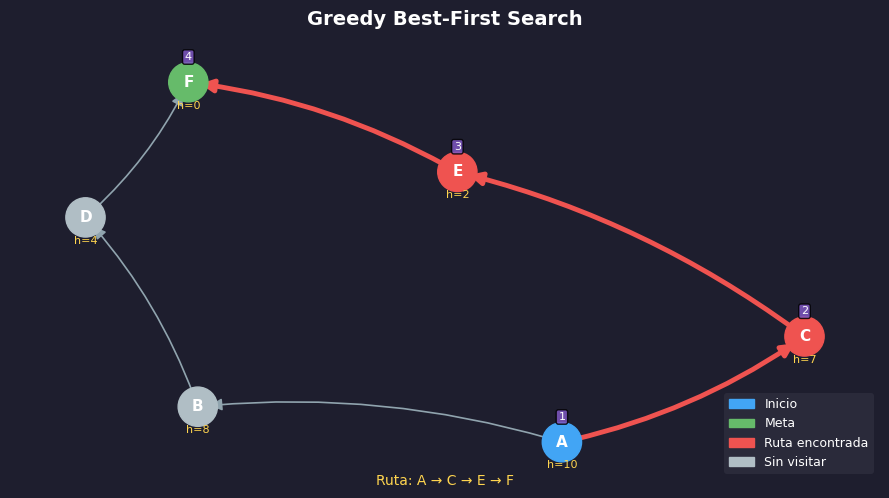

[Greedy] Orden de visita: ['A', 'C', 'E', 'F']
[Greedy] Ruta final:      ['A', 'C', 'E', 'F']


In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import heapq

# ─────────────────────────────────────────
# DATOS DEFINIDOS PREVIAMENTE
# ─────────────────────────────────────────
heuristics = {'A': 10, 'B': 8, 'C': 7, 'D': 4, 'E': 2, 'F': 0}
graph = {'A': ['B', 'C'], 'B': ['D'], 'C': ['E'], 'D': ['F'], 'E': ['F']}
weighted_graph = {'A': {'B': 5, 'C': 2}, 'B': {'D': 4}, 'C': {'D': 8}, 'D': {}}

# ─────────────────────────────────────────
# UTILIDADES DE VISUALIZACIÓN
# ─────────────────────────────────────────
PALETTE = {
    'default_node':  '#B0BEC5',
    'visited_node':  '#FFA726',
    'path_node':     '#EF5350',
    'goal_node':     '#66BB6A',
    'start_node':    '#42A5F5',
    'default_edge':  '#90A4AE',
    'path_edge':     '#EF5350',
    'bg':            '#1E1E2E',
    'text':          'white',
}

def build_path_sets(path):
    """Devuelve nodos y aristas del camino como conjuntos."""
    path_nodes = set(path)
    path_edges = set()
    for i in range(len(path) - 1):
        path_edges.add((path[i], path[i + 1]))
        path_edges.add((path[i + 1], path[i]))   # aristas no dirigidas
    return path_nodes, path_edges

def get_node_colors(G, path, start, goal):
    colors = []
    path_nodes, _ = build_path_sets(path)
    for node in G.nodes():
        if node == goal:
            colors.append(PALETTE['goal_node'])
        elif node == start:
            colors.append(PALETTE['start_node'])
        elif node in path_nodes:
            colors.append(PALETTE['path_node'])
        else:
            colors.append(PALETTE['default_node'])
    return colors

def get_edge_colors(G, path):
    _, path_edges = build_path_sets(path)
    return [
        PALETTE['path_edge'] if (u, v) in path_edges else PALETTE['default_edge']
        for u, v in G.edges()
    ]

def get_edge_widths(G, path):
    _, path_edges = build_path_sets(path)
    return [3.5 if (u, v) in path_edges else 1.2 for u, v in G.edges()]

def base_fig(title):
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor(PALETTE['bg'])
    ax.set_facecolor(PALETTE['bg'])
    ax.set_title(title, color=PALETTE['text'], fontsize=14, fontweight='bold', pad=14)
    ax.axis('off')
    return fig, ax

def draw_legend(ax, items):
    patches = [mpatches.Patch(color=c, label=l) for l, c in items]
    ax.legend(handles=patches, loc='lower right',
              facecolor='#2E2E3E', edgecolor='none',
              labelcolor=PALETTE['text'], fontsize=9)

# ─────────────────────────────────────────
# 1. GREEDY BEST-FIRST SEARCH
# ─────────────────────────────────────────
def greedy_best_first(graph, start, goal, heuristics):
    """Retorna (camino, orden_de_visita)."""
    open_list = [(heuristics[start], start, [start])]
    visited = []
    while open_list:
        _, node, path = min(open_list, key=lambda x: x[0])
        open_list = [x for x in open_list if x[1] != node]
        visited.append(node)
        if node == goal:
            return path, visited
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                open_list.append((heuristics[neighbor], neighbor, path + [neighbor]))
    return [], visited

def plot_greedy(graph, heuristics, start='A', goal='F'):
    path, visited = greedy_best_first(graph, start, goal, heuristics)

    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for nb in neighbors:
            G.add_edge(node, nb)

    pos = nx.spring_layout(G, seed=42)
    node_colors = get_node_colors(G, path, start, goal)
    edge_colors = get_edge_colors(G, path)
    edge_widths = get_edge_widths(G, path)

    fig, ax = base_fig("Greedy Best-First Search")

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowsize=18,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_color=PALETTE['text'], font_size=11, font_weight='bold')

    # Etiquetas con heurística
    h_labels = {n: f"h={heuristics[n]}" for n in G.nodes()}
    label_pos = {n: (p[0], p[1] - 0.12) for n, p in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=h_labels, ax=ax,
                            font_color='#FFD54F', font_size=8)

    # Orden de visita sobre nodos del camino
    for i, node in enumerate(visited):
        x, y = pos[node]
        ax.text(x, y + 0.13, str(i + 1), ha='center', va='center',
                fontsize=8, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#7E57C2', alpha=0.85))

    draw_legend(ax, [
        ('Inicio', PALETTE['start_node']),
        ('Meta', PALETTE['goal_node']),
        ('Ruta encontrada', PALETTE['path_node']),
        ('Sin visitar', PALETTE['default_node']),
    ])

    info = f"Ruta: {' → '.join(path)}"
    fig.text(0.5, 0.02, info, ha='center', color='#FFD54F', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"[Greedy] Orden de visita: {visited}")
    print(f"[Greedy] Ruta final:      {path}")

plot_greedy(graph, heuristics)


## 2. HILL CLIMBING

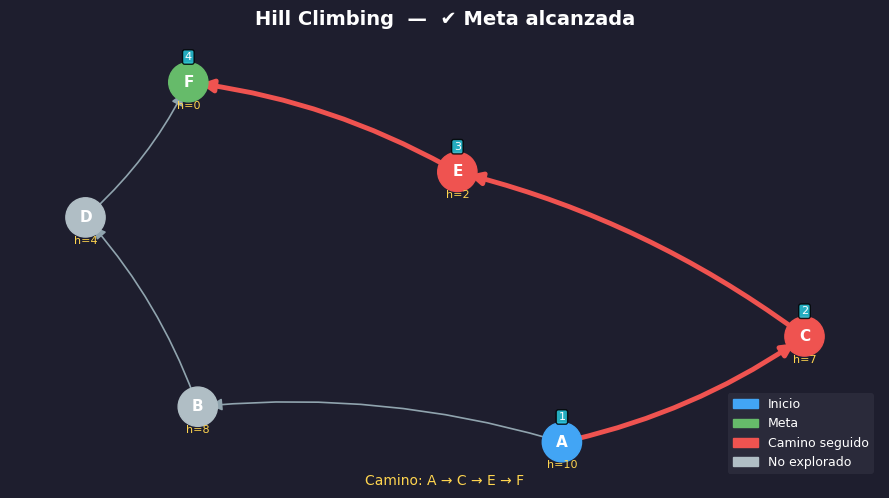

[Hill Climbing] Camino:        ['A', 'C', 'E', 'F']
[Hill Climbing] Meta alcanzada: True


In [24]:
# ─────────────────────────────────────────
# 2. HILL CLIMBING
# ─────────────────────────────────────────
def hill_climbing(graph, start, goal, heuristics):
    """
    Sube a vecinos con menor heurística.
    Se detiene en la meta o en un máximo local.
    """
    path = [start]
    current = start
    while current != goal:
        neighbors = graph.get(current, [])
        if not neighbors:
            break   # máximo local (sin salida)
        # Escoge el vecino con menor h (más prometedor)
        best = min(neighbors, key=lambda n: heuristics[n])
        if heuristics[best] >= heuristics[current]:
            break   # máximo local (ningún vecino mejora)
        path.append(best)
        current = best
    return path, current == goal

def plot_hill_climbing(graph, heuristics, start='A', goal='F'):
    path, reached_goal = hill_climbing(graph, start, goal, heuristics)

    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for nb in neighbors:
            G.add_edge(node, nb)

    pos = nx.spring_layout(G, seed=42)
    node_colors = get_node_colors(G, path, start, goal)
    edge_colors = get_edge_colors(G, path)
    edge_widths = get_edge_widths(G, path)

    status = "✔ Meta alcanzada" if reached_goal else "✘ Máximo local (sin solución)"
    fig, ax = base_fig(f"Hill Climbing  —  {status}")

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowsize=18,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_color=PALETTE['text'], font_size=11, font_weight='bold')

    h_labels = {n: f"h={heuristics[n]}" for n in G.nodes()}
    label_pos = {n: (p[0], p[1] - 0.12) for n, p in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=h_labels, ax=ax,
                            font_color='#FFD54F', font_size=8)

    # Numeración del camino
    for i, node in enumerate(path):
        x, y = pos[node]
        ax.text(x, y + 0.13, str(i + 1), ha='center', va='center',
                fontsize=8, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#26C6DA', alpha=0.85))

    draw_legend(ax, [
        ('Inicio', PALETTE['start_node']),
        ('Meta', PALETTE['goal_node']),
        ('Camino seguido', PALETTE['path_node']),
        ('No explorado', PALETTE['default_node']),
    ])

    info = f"Camino: {' → '.join(path)}"
    fig.text(0.5, 0.02, info, ha='center', color='#FFD54F', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"[Hill Climbing] Camino:        {path}")
    print(f"[Hill Climbing] Meta alcanzada: {reached_goal}")

plot_hill_climbing(graph, heuristics)


## 3. BRANCH AND BOUND

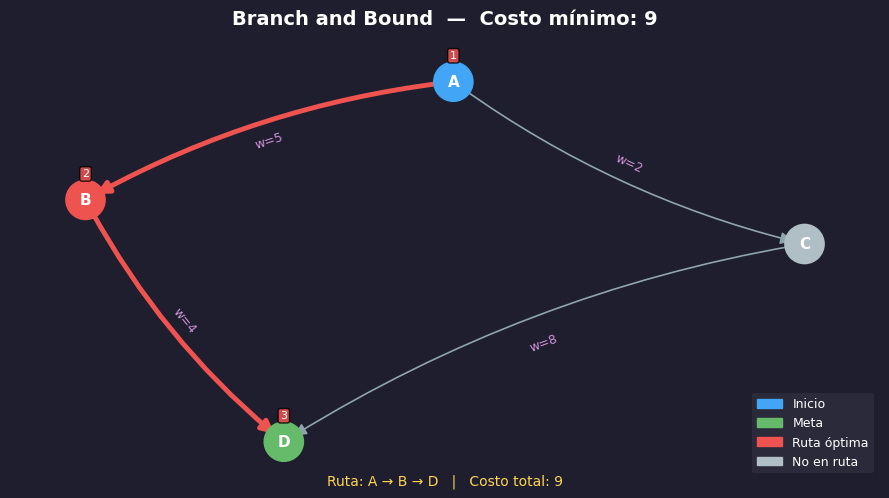

[Branch & Bound] Ruta óptima:  ['A', 'B', 'D']
[Branch & Bound] Costo total:  9


In [25]:
# ─────────────────────────────────────────
# 3. BRANCH AND BOUND
# ─────────────────────────────────────────
def branch_and_bound(weighted_graph, start, goal):
    """
    Búsqueda Branch & Bound con costo de camino acumulado.
    Retorna (mejor_camino, costo_total).
    """
    # heap: (costo_acumulado, nodo_actual, camino)
    heap = [(0, start, [start])]
    best_cost = float('inf')
    best_path = []

    while heap:
        cost, node, path = heapq.heappop(heap)

        if cost >= best_cost:
            continue   # poda: ya hay una solución mejor

        if node == goal:
            best_cost = cost
            best_path = path
            continue

        for neighbor, weight in weighted_graph.get(node, {}).items():
            new_cost = cost + weight
            if new_cost < best_cost and neighbor not in path:
                heapq.heappush(heap, (new_cost, neighbor, path + [neighbor]))

    return best_path, best_cost

def plot_branch_and_bound(weighted_graph, start='A', goal='D'):
    path, total_cost = branch_and_bound(weighted_graph, start, goal)

    G = nx.DiGraph()
    edge_weight_labels = {}
    for node, neighbors in weighted_graph.items():
        for nb, w in neighbors.items():
            G.add_edge(node, nb, weight=w)
            edge_weight_labels[(node, nb)] = f"w={w}"

    pos = nx.spring_layout(G, seed=7)
    node_colors = get_node_colors(G, path, start, goal)
    edge_colors = get_edge_colors(G, path)
    edge_widths = get_edge_widths(G, path)

    fig, ax = base_fig(f"Branch and Bound  —  Costo mínimo: {total_cost}")

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowsize=18,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_color=PALETTE['text'], font_size=11, font_weight='bold')

    # Pesos de aristas
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weight_labels, ax=ax,
                                 font_color='#CE93D8', font_size=9,
                                 bbox=dict(alpha=0))

    # Numeración del camino óptimo
    for i, node in enumerate(path):
        x, y = pos[node]
        ax.text(x, y + 0.13, str(i + 1), ha='center', va='center',
                fontsize=8, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#EF5350', alpha=0.85))

    draw_legend(ax, [
        ('Inicio', PALETTE['start_node']),
        ('Meta', PALETTE['goal_node']),
        ('Ruta óptima', PALETTE['path_node']),
        ('No en ruta', PALETTE['default_node']),
    ])

    info = f"Ruta: {' → '.join(path)}   |   Costo total: {total_cost}"
    fig.text(0.5, 0.02, info, ha='center', color='#FFD54F', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"[Branch & Bound] Ruta óptima:  {path}")
    print(f"[Branch & Bound] Costo total:  {total_cost}")

plot_branch_and_bound(weighted_graph)
